# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 48     |  |
| :-------------|:-------------|
| Emma Jule Drent | 6507417 |
| Yu He Zhang| 6455417 |
| Chinming Zhu| 6325971 |

## Opdracht 1: Planning.

| Planning Groep: 48     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11.00-12.30 | Chinming |
| ontwerp-eis berekenen| 11.00-12.30 | Emma Jule en Yu He|
| Synthese, simulatie en evulatie | 13.30-14.30 | hele groep |
| Fabricage, evaluatie en metingen doen | 15.30 | hele groep |
| Inleveren | 17.00 | ---|
| Opstelling werkend | 16.00 | ---|
| Pauze 1| 12.30-13.30 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math
from scipy.optimize import curve_fit

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 6 |
| hoe lang voor één meting | 3 seconden |
| verwacht nauwkeurigheid meting | 5% |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie

# 1/3 = A_m/A_v
# 1/3 = 1/(1-(100pi^2/omega_0))
# omega_0 = 5pi
# frequentie = 5/2

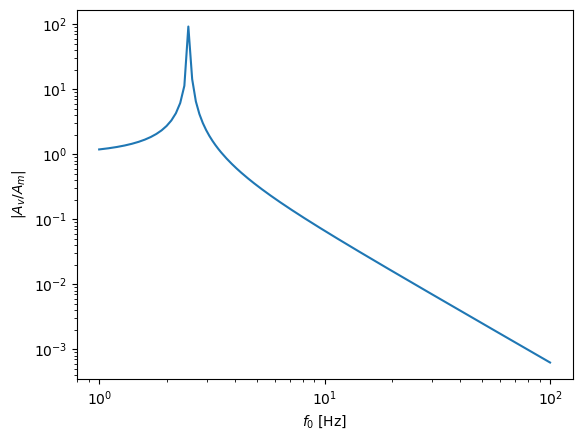

In [3]:
# Plotten amplitude overdracht
f_0 = 5/2

def Am_Av(omega):
    return np.abs(1/(1-((omega)**2/(f_0)**2)))

x = np.linspace(1,100,1000)
y1 = Am_Av(x)


# Plot
plt.figure()
plt.loglog((x),(y1))
plt.xlabel("$f_0$ [Hz]")
plt.ylabel("$|A_v/A_m|$")
plt.show()


In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.

omega_0 = 5*np.pi
dx = 9.81 / omega_0**2
print(dx, "m")

0.039758432461253344 m


## Opdracht 3: Plot de grafiek.

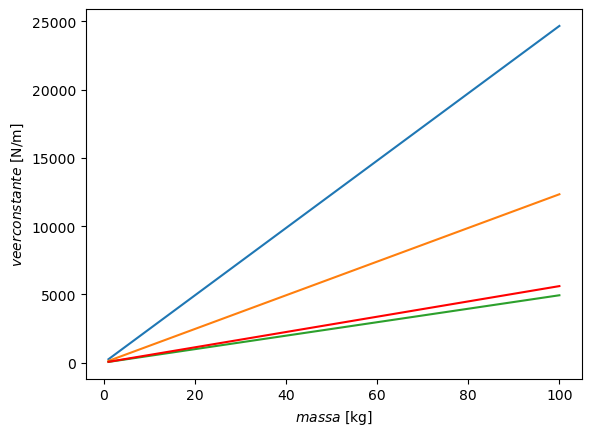

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

g = 9.81
def veerconstante(m,x):
    return (m*g)/x

massa = np.linspace(1,100,1000)

plt.figure()
plt.plot(massa,veerconstante(massa,dx))
plt.plot(massa,veerconstante(massa,dx)/2)
plt.plot(massa,veerconstante(massa,dx)/5)
plt.plot(massa,veerconstante(massa,0.035)/5, "r-")  # Bij bepaalde uitwijking
plt.xlabel("$massa$ [kg]")
plt.ylabel("$veerconstante$ [N/m]")
plt.savefig("Veerconstante_massa")
plt.show()


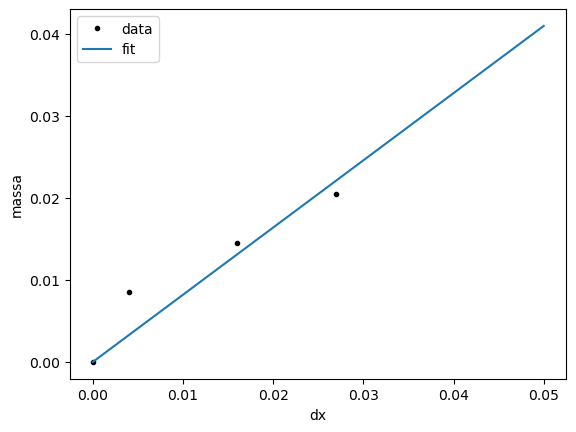

De geschatte veerconstante van de veer is 8.031263738499582 N/m


In [6]:
# Bepalen van massa bij gebruikte veren.

L_test = 0.078
dx_test = np.array([8.2,9.4,10.5,0.078*100])/100 - L_test
m_test = np.array([8.5,14.5,20.5,0])/1000

def massafit(dx,C):
    return C * dx / 9.81

val, cov = curve_fit(massafit,dx_test,m_test)
C_fit = val[0]

xfit = np.linspace(0,0.05,100)
yfit = massafit(xfit,C_fit)

plt.figure()
plt.plot(dx_test, m_test, "k.", label="data")
plt.plot(xfit,yfit, label="fit")
plt.xlabel("dx")
plt.ylabel("massa")
plt.legend()
plt.show()

print(f"De geschatte veerconstante van de veer is {C_fit} N/m")

In [7]:
print(f"{massafit(0.035,4*C_fit)*1000} gram is nodig voor de opstelling.")

114.61538464729271 gram is nodig voor de opstelling.


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- veerconstante verkleinen
- massa vergroten

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 0.035 m. We gaan uit van een onzekerheid van ongeveer een halve centimeter, dus vandaar.

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="Schets.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

0.035 meter.

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja.

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Limiet is 30 cm.

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Onze metingen overschrijden het limiet niet, dus dat is goed.

### Gaat je ontwerp dus voldoen aan de eis?

Ja!

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

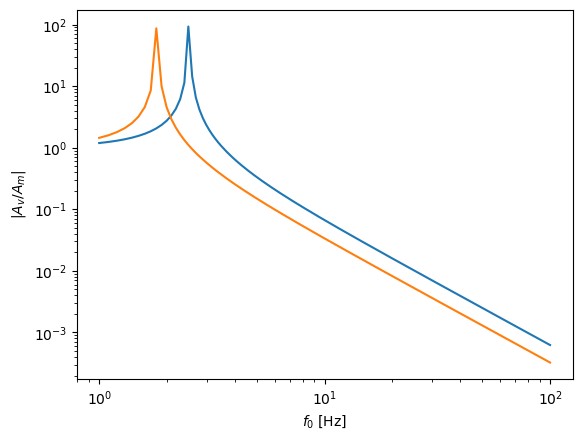

In [8]:
# Voeg hier je plot in.

# Plotten amplitude overdracht
f_0 = 5/2

def Am_Av(omega):
    return np.abs(1/(1-((omega)**2/(f_0)**2)))

f = np.linspace(1,100,1000)
y1 = Am_Av(f)

def Am_Av_opstelling(omega):
    return np.abs(1/(1-((omega)**2/(11.33/(2*np.pi))**2)))  # omega0 = sqrt(g/dx) =  11.33, bij m= 0.2 kg en C = 4 * 8.03
y2 = Am_Av_opstelling(f)

# Plot
plt.figure()
plt.loglog((f), (y1))
plt.loglog((f), (y2))
plt.xlabel("$f_0$ [Hz]")
plt.ylabel("$|A_v/A_m|$")
plt.show()


## Opdracht 7: Plotten maar

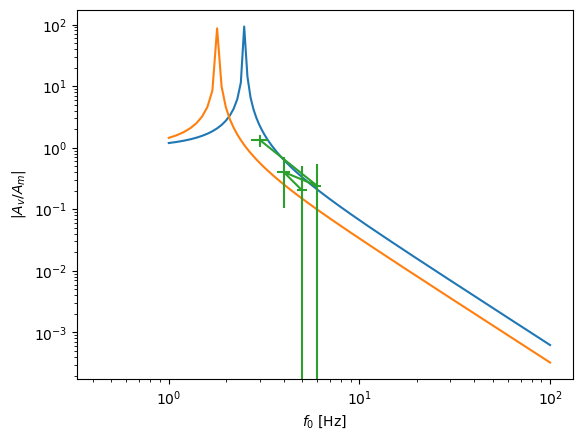

In [9]:
# Voeg hier je plots in.
f_meting = np.array([5.0, 4.0, 6.0, 3.0])
Am_meting = np.array([0.79, 1.16, 1.18 , 3.25])
Av_meting = np.array([3.89, 2.87, 4.91 , 2.43])
Am_Av_meting = Am_meting/Av_meting

plt.figure()
plt.loglog((f), (y1))
plt.loglog((f), (y2))
plt.errorbar(f_meting, Am_Av_meting, xerr=0.3, yerr=0.3) # Frequentiefout is 0.3, factorfout = 0.3
plt.xlabel("$f_0$ [Hz]")
plt.ylabel("$|A_v/A_m|$")
plt.show()


## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

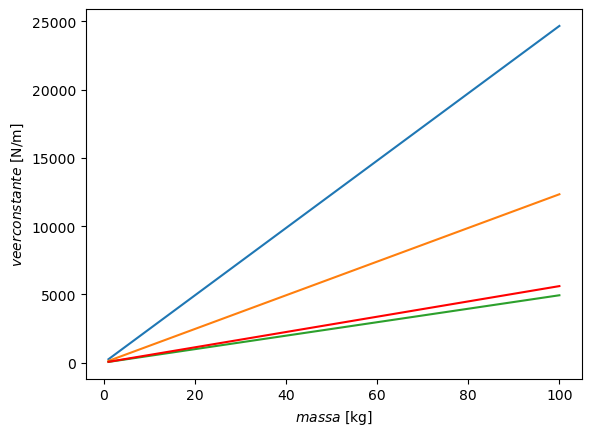

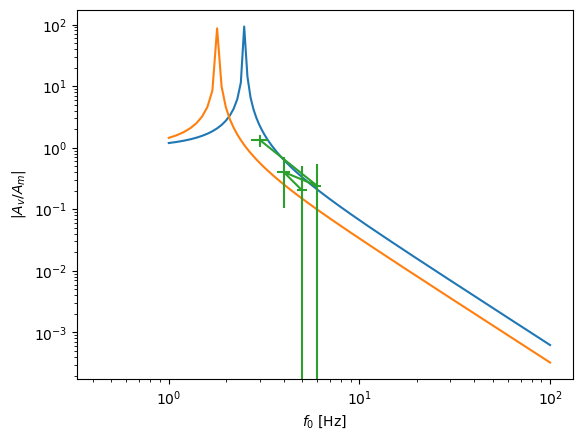

In [10]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

g = 9.81
def veerconstante(m,x):
    return (m*g)/x

massa = np.linspace(1,100,1000)

plt.figure()
plt.plot(massa,veerconstante(massa,dx))
plt.plot(massa,veerconstante(massa,dx)/2)
plt.plot(massa,veerconstante(massa,dx)/5)
plt.plot(massa,veerconstante(massa,0.035)/5, "r-")  # Bij bepaalde uitwijking
plt.xlabel("$massa$ [kg]")
plt.ylabel("$veerconstante$ [N/m]")
plt.savefig("Veerconstante_massa")
plt.show()


# Voeg hier je plots in.
f_meting = np.array([5.0, 4.0, 6.0, 3.0])
Am_meting = np.array([0.79, 1.16, 1.18 , 3.25])
Av_meting = np.array([3.89, 2.87, 4.91 , 2.43])
Am_Av_meting = Am_meting/Av_meting

plt.figure()
plt.loglog((f), (y1))
plt.loglog((f), (y2))
plt.errorbar(f_meting, Am_Av_meting, xerr=0.3, yerr=0.3) # Frequentiefout is 0.3, factorfout = 0.3
plt.xlabel("$f_0$ [Hz]")
plt.ylabel("$|A_v/A_m|$")
plt.show()




#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
<img src="Veerconstante_massa.png" width="400">
